### Content:
- compute average trip duration 
- plot number of trips per day
- plot count of number of trips for day of the week
- plot count of number of trips by hour of the day
- plot trips by hour for each operator: wind vs BIT e-scooters
- plot usage by month
- plot cumulative time of usage per day 



In [8]:
import os
import sys 
from google.colab import drive 
import glob

path = "/content/drive" 
drive.mount(path, force_remount=True)  
data_path = "drive/MyDrive/Colab Notebooks/escooter_TN" 

myfiles = glob.glob(os.path.join(data_path, '*')) 
print(myfiles)

Mounted at /content/drive
['drive/MyDrive/Colab Notebooks/escooter_TN/check_datasets-delete.ipynb', 'drive/MyDrive/Colab Notebooks/escooter_TN/trento.pbf', 'drive/MyDrive/Colab Notebooks/escooter_TN/traiettorie.ipynb', 'drive/MyDrive/Colab Notebooks/escooter_TN/traiettorie_con_MovingPandas.ipynb', 'drive/MyDrive/Colab Notebooks/escooter_TN/dataviz_spostamenti_2022.html', 'drive/MyDrive/Colab Notebooks/escooter_TN/dataviz_spostamenti_monopattini.ipynb', 'drive/MyDrive/Colab Notebooks/escooter_TN/ExploreTrips.ipynb', 'drive/MyDrive/Colab Notebooks/escooter_TN/0_clean_data.ipynb', 'drive/MyDrive/Colab Notebooks/escooter_TN/trips_pointv3_cleaned.parquet']


In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [147]:
df = pd.read_parquet(data_path+'/trips_pointv3_cleaned.parquet')

In [148]:
df

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,date,unique_id
0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07
1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07
2,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:15+00:00,46.052905,11.120811,15,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07
3,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:24+00:00,46.052874,11.121122,16,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07
4,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:35+00:00,46.052732,11.121525,17,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07
...,...,...,...,...,...,...,...,...,...
997228,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:06:41+00:00,46.079951,11.117475,3,2022-03-04,66cff91f-babc-4560-b5c3-a6cc53c6d371_2022-03-04
997229,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:06:51+00:00,46.079677,11.117734,4,2022-03-04,66cff91f-babc-4560-b5c3-a6cc53c6d371_2022-03-04
997230,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:07:01+00:00,46.079403,11.117844,5,2022-03-04,66cff91f-babc-4560-b5c3-a6cc53c6d371_2022-03-04
997231,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:07:11+00:00,46.079176,11.117913,6,2022-03-04,66cff91f-babc-4560-b5c3-a6cc53c6d371_2022-03-04


In [149]:
len(pd.unique(df.unique_id)) # number of trips

87923

### Average trip duration

In [150]:
# dictionary with IDs as keys ("unique_id") and as value a dict with "point_sequence" as key and "point_timestamp" as value
d={}
for r in range(len(df)):
  if df.unique_id[r] not in d.keys():
    inner_d = {}
    inner_d[df.point_sequence[r]]=df.point_timestamp[r]
    d[df.unique_id[r]] = inner_d
  else:
    d[df.unique_id[r]][df.point_sequence[r]]=df.point_timestamp[r]

In [151]:
l=[]
for k in d.keys():
  duration = d[k][max(d[k].keys())] - d[k][min(d[k].keys())]
  l.append((k, duration))
l

[('24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07',
  Timedelta('0 days 00:06:40')),
 ('1dac7a0b-0ab2-4f61-8b5b-01f8ad49b5ce_2022-01-08',
  Timedelta('0 days 00:08:02')),
 ('ca12a6aa-ec84-40d9-a6f2-a98e2c24cd26_2022-01-08',
  Timedelta('0 days 00:02:44')),
 ('da0a08f3-5bc2-40c3-9ee7-f2ef0b68905b_2022-01-08',
  Timedelta('0 days 00:06:09')),
 ('546cad2e-5cf3-496c-9182-e7caa4bff556_2022-01-08',
  Timedelta('0 days 00:15:05')),
 ('00000b31-0000-1000-9801-5b7d6a617b60_2022-01-18',
  Timedelta('0 days 00:06:20')),
 ('0000125a-0000-1000-9cba-5b7d6a617b60_2022-01-18',
  Timedelta('0 days 00:00:00')),
 ('00000ade-0000-1000-8a7e-5b7d6a617b60_2022-01-18',
  Timedelta('0 days 00:07:11')),
 ('000003fa-0000-1000-926a-5b7d6a617b60_2022-01-18',
  Timedelta('0 days 00:02:10')),
 ('000015a5-0000-1000-90c5-5b7d6a617b60_2022-01-18',
  Timedelta('0 days 00:11:24')),
 ('000020a9-0000-1000-9809-5b7d6a617b60_2022-01-18',
  Timedelta('0 days 00:14:46')),
 ('00002032-0000-1000-a432-5b7d6a617b60_2022-01-18',
 

In [152]:
s=pd.Timedelta('0')
for el in l:
  s+=el[1]
avg=s/len(l)

print(avg)

print('The average trip is approximately %d minutes long.' % int((avg.seconds//60)%60))

0 days 00:09:25.298863778
The average trip is approximately 9 minutes long.


Boxplot

In [153]:
df = df.sort_values(by=['point_timestamp', 'unique_id'])
df.point_longitude = df.point_longitude.astype(float)
df.point_latitude = df.point_latitude.astype(float)

In [154]:
new_df = df.groupby('unique_id', as_index=False).aggregate({"point_latitude": lambda x: x.to_list(),"point_longitude": lambda x: x.to_list(), "point_timestamp":lambda x: x.to_list()})
new_df["coords"] = [ [[k,v] for k,v in zip(i,j)] for i,j in zip(new_df["point_latitude"], new_df["point_longitude"])]
new_df

,unique_id,point_latitude,point_longitude,point_timestamp,coords
0,00000000-0000-1000-8000-5b7d6a617b60_2021-06-10,"[46.071407, 46.060551]","[11.119391, 11.115241]","[2021-06-10 06:14:15+00:00, 2021-06-10 06:26:2...","[[46.071407, 11.119391], [46.060551, 11.115241]]"
1,00000000-0000-1000-8000-5b7d6a617b60_2021-07-31,"[46.075313, 46.060999]","[11.123848, 11.124701]","[2021-07-31 16:48:36+00:00, 2021-07-31 17:03:3...","[[46.075313, 11.123848], [46.060999, 11.124701]]"
2,00000000-0000-1000-8000-5b7d6a617b60_2021-08-05,"[46.051605, 46.090282]","[11.124385, 11.115124]","[2021-08-05 19:37:04+00:00, 2021-08-05 19:57:0...","[[46.051605, 11.124385], [46.090282, 11.115124]]"
3,00000000-0000-1000-8000-5b7d6a617b60_2021-09-28,"[46.062508, 46.090313]","[11.123746, 11.115117]","[2021-09-28 17:29:15+00:00, 2021-09-28 17:41:1...","[[46.062508, 11.123746], [46.090313, 11.115117]]"
4,00000000-0000-1000-8000-5b7d6a617b60_2021-10-01,"[46.066395, 46.069542]","[11.125643, 11.119864]","[2021-10-01 19:34:39+00:00, 2021-10-01 19:37:5...","[[46.066395, 11.125643], [46.069542, 11.119864]]"
...,...,...,...,...,...
87918,fff6b734bab3_2021-04-22,"[46.086395, 46.086609]","[11.119722, 11.119655]","[2021-04-22 17:10:48+00:00, 2021-04-22 17:10:5...","[[46.086395, 11.119722], [46.086609, 11.119655]]"
87919,fff737605a72_2021-07-19,"[46.067644, 46.067652, 46.067649, 46.067658, 4...","[11.120354, 11.120353, 11.120356, 11.120348, 1...","[2021-07-19 11:37:02+00:00, 2021-07-19 11:37:0...","[[46.067644, 11.120354], [46.067652, 11.120353..."
87920,fff77d5c39b5_2021-06-07,"[46.07034, 46.070321, 46.070314, 46.070269, 46...","[11.124557, 11.124557, 11.124554, 11.12457, 11...","[2021-06-07 16:25:20+00:00, 2021-06-07 16:25:2...","[[46.07034, 11.124557], [46.070321, 11.124557]..."
87921,fff9fc12b926_2021-06-09,"[46.078064, 46.077972]","[11.123182, 11.123108]","[2021-06-09 06:33:31+00:00, 2021-06-09 06:39:3...","[[46.078064, 11.123182], [46.077972, 11.123108]]"


In [155]:
tt=[]
trip_duration_sec=[]
trip_duration_min=[]
trip_duration_h=[]
for i in range(len(new_df)): 
  trip_time = new_df.point_timestamp[i][-1] - new_df.point_timestamp[i][0]
  tt.append(trip_time)
  trip_duration_sec.append(trip_time.components.hours *60*60 + trip_time.components.minutes * 60 + trip_time.components.seconds)
  trip_duration_min.append(trip_time.components.hours *60 + trip_time.components.minutes)
  trip_duration_h.append(trip_time.components.hours)
new_df['trip_time'] = tt
new_df['trip_time_seconds'] = trip_duration_sec
new_df['trip_time_minutes'] = trip_duration_min
new_df['trip_time_hours'] = trip_duration_h

In [156]:
new_df.head(2)

,unique_id,point_latitude,point_longitude,point_timestamp,coords,trip_time,trip_time_seconds,trip_time_minutes,trip_time_hours
0,00000000-0000-1000-8000-5b7d6a617b60_2021-06-10,"[46.071407, 46.060551]","[11.119391, 11.115241]","[2021-06-10 06:14:15+00:00, 2021-06-10 06:26:2...","[[46.071407, 11.119391], [46.060551, 11.115241]]",0 days 00:12:08,728,12,0
1,00000000-0000-1000-8000-5b7d6a617b60_2021-07-31,"[46.075313, 46.060999]","[11.123848, 11.124701]","[2021-07-31 16:48:36+00:00, 2021-07-31 17:03:3...","[[46.075313, 11.123848], [46.060999, 11.124701]]",0 days 00:14:54,894,14,0


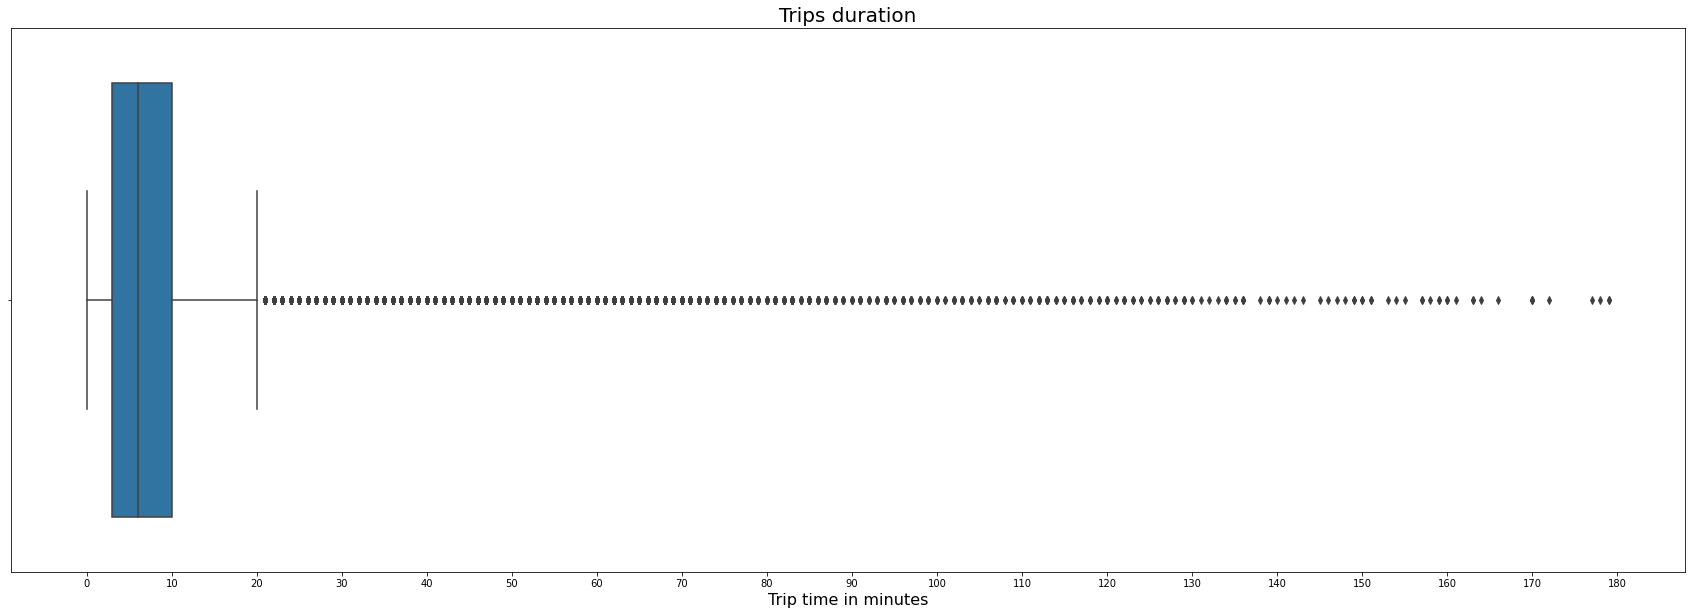

In [157]:
plt.figure(figsize=(30,10))

g = sns.boxplot(x='trip_time_minutes', data=new_df)
g.set_xlabel('Trip time in minutes',fontsize=16)
g.set_title('Trips duration',fontsize= 20)
g.set_xticks(range(0, 181, 10))

plt.show()

In [158]:
h = new_df[new_df.trip_time_hours != 0]
m = new_df[new_df.trip_time_minutes > 20]

In [159]:
print('Outiliers with time greater than one hour are', len(h), 'over a total of', len(new_df), 'trips.')
print('Outiliers with time greater than 20 minutes are', len(m), 'over a total of', len(new_df), 'trips.')

Outiliers with time greater than one hour are 1056 over a total of 87923 trips.
Outiliers with time greater than 20 minutes are 7121 over a total of 87923 trips.


In [160]:
# remove outliers
new_df = new_df.drop(new_df[(new_df.trip_time_minutes > 20)].index)

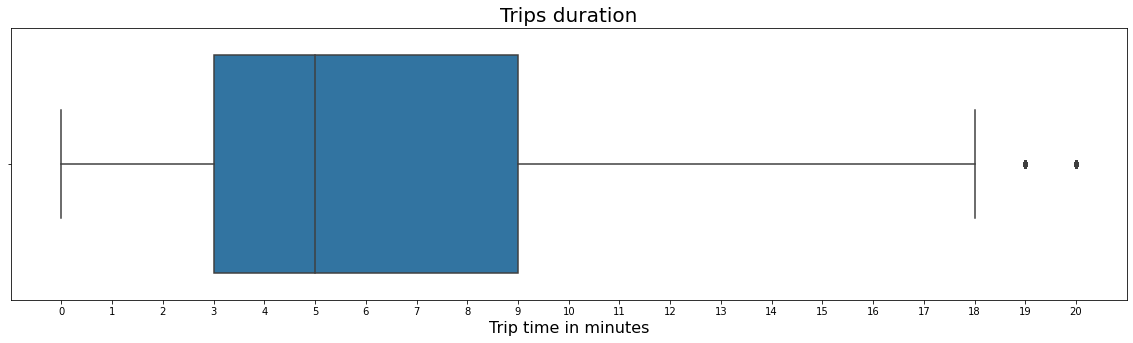

In [161]:
plt.figure(figsize=(20,5))

g = sns.boxplot(x='trip_time_minutes', data=new_df)
g.set_xlabel('Trip time in minutes',fontsize=16)
g.set_title('Trips duration',fontsize= 20)
g.set_xticks(range(21))

plt.show()

Media e mediana

In [162]:
new_df.trip_time_minutes.mean() # media

6.24359545555803

In [163]:
new_df.trip_time_minutes.median() # mediana

5.0

In [164]:
h = h.reset_index()

In [165]:
# Most of the 1056 trips longer than an hour contains 2 points in time, 
# with a huge time gap between the first and the second point in time, 
# which it weird and may be the result of a mistake in recording.

# Only 24 of them contain more than 2 points in time and they may be 
# the result of a concatenation of two trips,
# or else of an unusual long trip of some users.

q=[]
for pt in range(len(h)):
  if len(h.point_timestamp[pt]) > 2:
    q.append(h.point_timestamp[pt])
    print(h.point_timestamp[pt])
# len(q) # 24

[Timestamp('2021-05-27 19:50:57+0000', tz='UTC'), Timestamp('2021-05-27 19:51:03+0000', tz='UTC'), Timestamp('2021-05-27 19:56:34+0000', tz='UTC'), Timestamp('2021-05-27 19:56:39+0000', tz='UTC'), Timestamp('2021-05-27 19:56:44+0000', tz='UTC'), Timestamp('2021-05-27 19:56:54+0000', tz='UTC'), Timestamp('2021-05-27 19:56:59+0000', tz='UTC'), Timestamp('2021-05-27 19:57:04+0000', tz='UTC'), Timestamp('2021-05-27 20:10:35+0000', tz='UTC'), Timestamp('2021-05-27 20:10:40+0000', tz='UTC'), Timestamp('2021-05-27 20:10:45+0000', tz='UTC'), Timestamp('2021-05-27 21:40:07+0000', tz='UTC')]
[Timestamp('2021-06-29 07:06:35+0000', tz='UTC'), Timestamp('2021-06-29 07:06:40+0000', tz='UTC'), Timestamp('2021-06-29 07:06:45+0000', tz='UTC'), Timestamp('2021-06-29 07:06:50+0000', tz='UTC'), Timestamp('2021-06-29 07:06:55+0000', tz='UTC'), Timestamp('2021-06-29 07:07:00+0000', tz='UTC'), Timestamp('2021-06-29 07:07:05+0000', tz='UTC'), Timestamp('2021-06-29 07:07:19+0000', tz='UTC'), Timestamp('2021-06

Boxplot divided by week days

In [166]:
new_df = new_df.reset_index()

In [167]:
d=[]
for i in range(len(new_df)):
  d.append(new_df.point_timestamp[i][0].day_name())

In [168]:
new_df['weekday'] = d
new_df.head(2)

,index,unique_id,point_latitude,point_longitude,point_timestamp,coords,trip_time,trip_time_seconds,trip_time_minutes,trip_time_hours,weekday
0,0,00000000-0000-1000-8000-5b7d6a617b60_2021-06-10,"[46.071407, 46.060551]","[11.119391, 11.115241]","[2021-06-10 06:14:15+00:00, 2021-06-10 06:26:2...","[[46.071407, 11.119391], [46.060551, 11.115241]]",0 days 00:12:08,728,12,0,Thursday
1,1,00000000-0000-1000-8000-5b7d6a617b60_2021-07-31,"[46.075313, 46.060999]","[11.123848, 11.124701]","[2021-07-31 16:48:36+00:00, 2021-07-31 17:03:3...","[[46.075313, 11.123848], [46.060999, 11.124701]]",0 days 00:14:54,894,14,0,Saturday


In [169]:
new_df = new_df.sort_values(by=['weekday'])

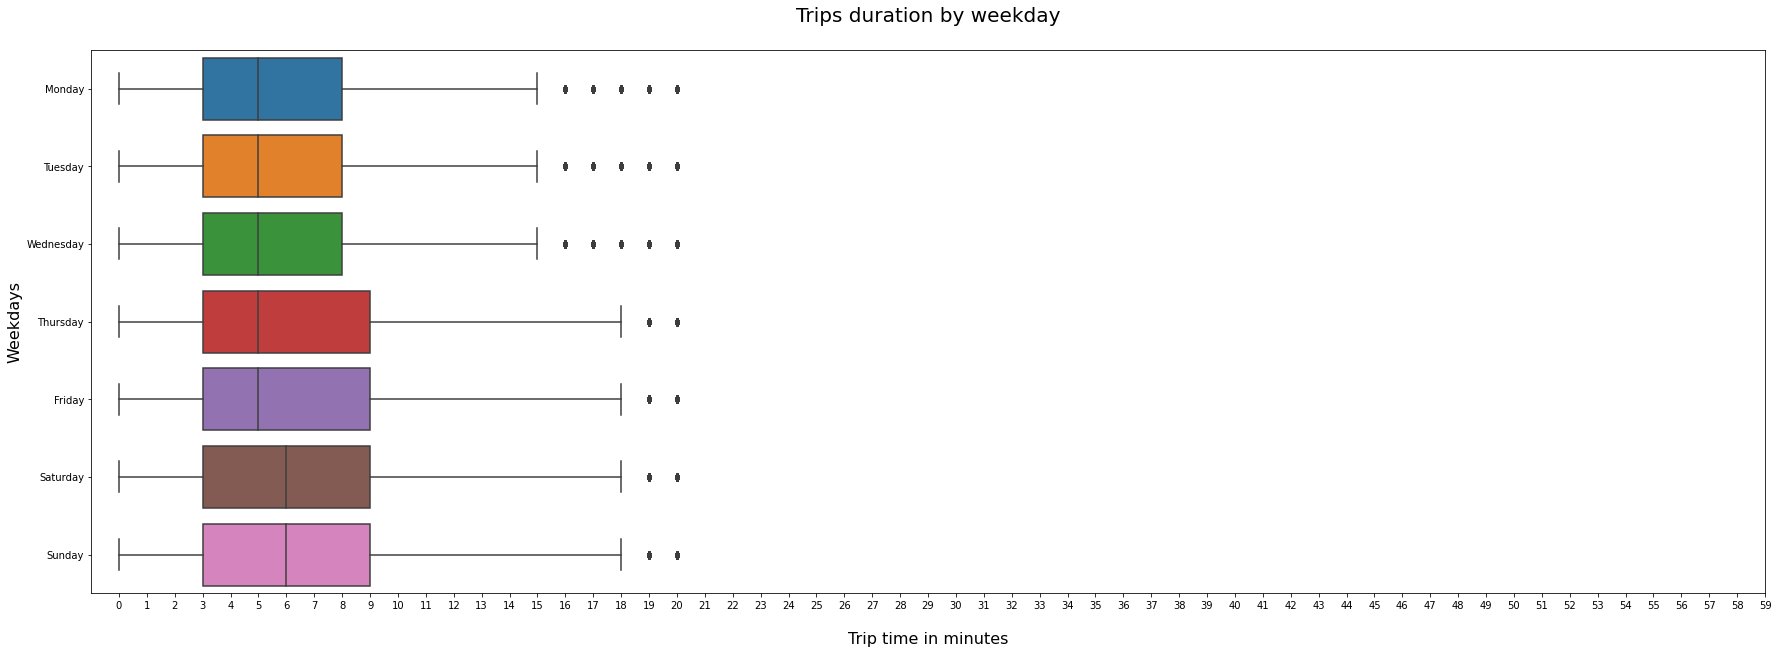

In [170]:
# From the boxplot below, one can notice a significant difference between weekdays and weekend in terms of median,
# as well as a change in the trips time going from the first three days of the week to the following.

plt.figure(figsize=(30,10))

g = sns.boxplot(x='trip_time_minutes', y='weekday', data=new_df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
g.set_xlabel('\nTrip time in minutes',fontsize=16)
g.set_ylabel('Weekdays',fontsize=16)
g.set_title('Trips duration by weekday\n',fontsize= 20)
g.set_xticks(range(60))

plt.show()

### Number of trips per day

In [171]:
daily_trips = df.groupby('date', as_index=False).aggregate({"point_sequence": lambda x: x.to_list()})

cnt=[]
for el in range(len(daily_trips)):
  cnt.append(daily_trips.point_sequence[el].count(0))

daily_trips['num_trips']=cnt
daily_trips=daily_trips.drop(['point_sequence'], axis=1)
  
daily_trips.tail()

,date,num_trips
433,2022-02-28,170
434,2022-03-01,181
435,2022-03-02,196
436,2022-03-03,279
437,2022-03-04,211


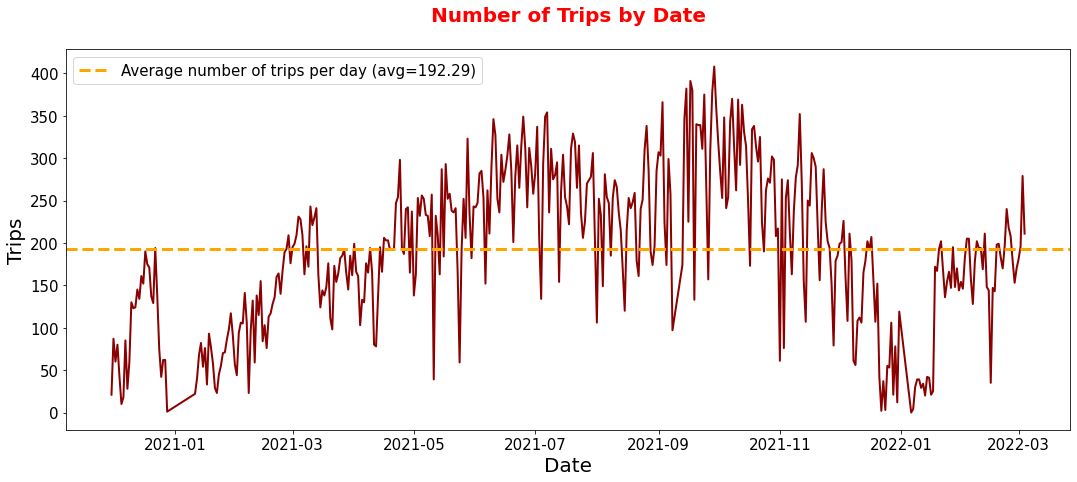

In [172]:
plt.figure(figsize = (18, 7))
plot = sns.lineplot(x = "date", y = "num_trips", data = daily_trips, color = "darkred", linewidth = 2)
avg_trips_num = daily_trips["num_trips"].mean()
plot.axhline(avg_trips_num, linestyle="--", color="orange", label="Average number of trips per day (avg="+str(round(avg_trips_num,2))+')', linewidth = 3) 
plt.title("Number of Trips by Date\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Date", size = 20, color = 'black')
plt.ylabel("Trips", size = 20, color = 'black')
plt.legend(prop={'size': 15})
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

### Number of trips by week day

In [173]:
df['day'] = df['point_timestamp'].dt.day_name()
df.head()

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,date,unique_id,day
80411,BIT,Bit Mobility,00000bf0-0000-1000-a6a0-5b7d6a617b60,2020-11-30 14:32:20+00:00,46.069790,11.121222,0,2020-11-30,00000bf0-0000-1000-a6a0-5b7d6a617b60_2020-11-30,Monday
80618,BIT,Bit Mobility,00000bf0-0000-1000-a6a0-5b7d6a617b60,2020-11-30 15:23:13+00:00,46.069786,11.115813,1,2020-11-30,00000bf0-0000-1000-a6a0-5b7d6a617b60_2020-11-30,Monday
80423,BIT,Bit Mobility,00001d90-0000-1000-8b30-5b7d6a617b60,2020-11-30 15:37:44+00:00,46.070271,11.120379,0,2020-11-30,00001d90-0000-1000-8b30-5b7d6a617b60_2020-11-30,Monday
80625,BIT,Bit Mobility,0000210d-0000-1000-8d7d-5b7d6a617b60,2020-11-30 15:42:50+00:00,46.067200,11.126792,0,2020-11-30,0000210d-0000-1000-8d7d-5b7d6a617b60_2020-11-30,Monday
80412,BIT,Bit Mobility,00001d90-0000-1000-8b30-5b7d6a617b60,2020-11-30 15:46:11+00:00,46.068718,11.115568,1,2020-11-30,00001d90-0000-1000-8b30-5b7d6a617b60_2020-11-30,Monday


In [174]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
trip_by_weekday = df.groupby('day')['day'].agg(["count"]).reindex(days).reset_index()
trip_by_weekday.columns = ["day_of_week", "num_trips"]
trip_by_weekday

,day_of_week,num_trips
0,Monday,140714
1,Tuesday,144537
2,Wednesday,145160
3,Thursday,155122
4,Friday,155388
5,Saturday,140731
6,Sunday,115581


In [175]:
trip_by_weekday["num_trips"].mean()

142461.85714285713

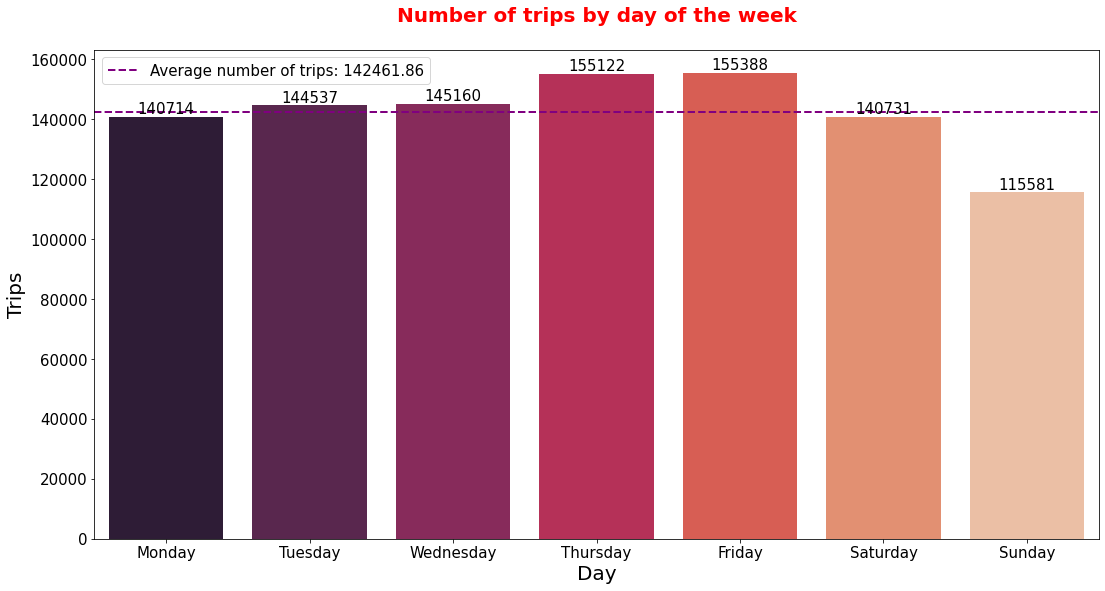

In [176]:
plt.figure(figsize = (18, 9))
plot = sns.barplot(x = "day_of_week", y = "num_trips", data = trip_by_weekday, palette = "rocket")
for p in plot.patches:
  plot.annotate('{:.0f}'.format(p.get_height()),
                (p.get_x()+0.4, p.get_height()),
                ha='center', va='bottom',color= 'black', size = 15)
plot.axhline(trip_by_weekday["num_trips"].mean(), linestyle="--", color="purple", label="Average number of trips: "+str(round(trip_by_weekday["num_trips"].mean(),2)), linewidth = 2) 
plt.title("Number of trips by day of the week\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Day", size = 20, color = 'black')
plt.ylabel("Trips", size = 20, color = 'black')
plt.legend(prop={'size': 15}, loc='upper left')
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

In [177]:
# It seems like in the weekends, expecially on Sundays, there are less trips, but 
# from the boxplot above, one can see that these trips tend to be longer
# with respect to weekdays.

### Trips by hour of the day

In [178]:
df['hour'] = df['point_timestamp'].dt.hour

trip_by_h = df['hour'].value_counts().to_frame().reset_index()
trip_by_h.columns = ['hour', 'num_trips']

trip_by_h

,hour,num_trips
0,16,91398
1,17,89638
2,15,84466
3,14,74313
4,18,73696
5,10,73612
6,11,71210
7,13,69506
8,12,69427
9,19,62156


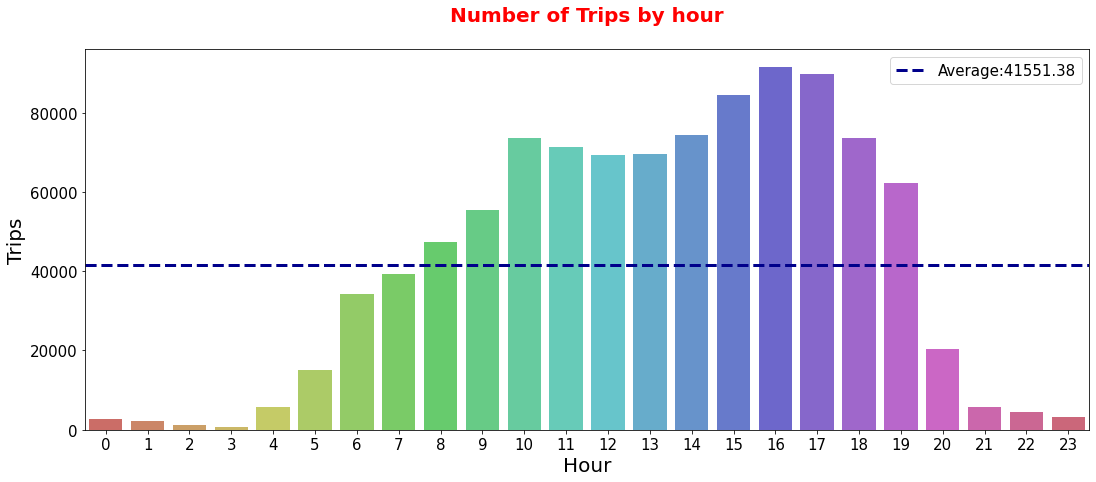

In [179]:
plt.figure(figsize = (18, 7))
plot = sns.barplot(x = 'hour', y = 'num_trips', data = trip_by_h, palette = "hls")
plot.axhline(trip_by_h['num_trips'].mean(), linestyle="--", color="darkblue", label="Average:"+str(round(trip_by_h['num_trips'].mean(), 2)), linewidth = 3) 
plt.title("Number of Trips by hour\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Hour", size = 20, color = 'black')
plt.ylabel("Trips", size = 20, color = 'black')
plt.legend(prop={'size': 15})
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

### Number of trips by the two different operators

In [180]:
pd.unique(df.operator)

array(['BIT', 'VENTO'], dtype=object)

In [181]:
op = df.groupby(['operator', 'hour'])['operator'].agg(["count"]).reset_index()
op.columns = ['operator', 'hour', 'num_trips']
op

,operator,hour,num_trips
0,BIT,0,293
1,BIT,1,218
2,BIT,2,145
3,BIT,3,124
4,BIT,4,733
5,BIT,5,3193
6,BIT,6,6662
7,BIT,7,6228
8,BIT,8,5734
9,BIT,9,6306


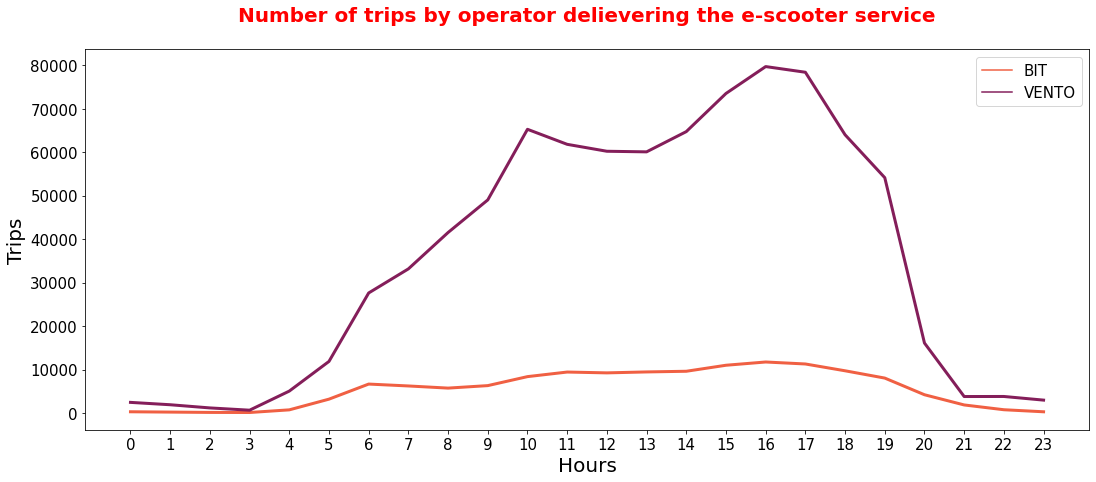

In [182]:
plt.figure(figsize = (18, 7))
sns.lineplot(x = 'hour', y = 'num_trips', hue = 'operator', data = op, palette = "rocket_r", linewidth = 3) 
plt.title("Number of trips by operator delievering the e-scooter service\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Hours", size = 20, color = "black")
plt.ylabel("Trips", size = 20, color = "black")
plt.legend(prop={'size': 15})
plt.xticks(range(0,24), size = 15)
plt.yticks(size = 15)
plt.show()

### Usage by month

In [183]:
df['month'] = pd.to_datetime(df['date']).dt.month
df.head()

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,date,unique_id,day,hour,month
80411,BIT,Bit Mobility,00000bf0-0000-1000-a6a0-5b7d6a617b60,2020-11-30 14:32:20+00:00,46.069790,11.121222,0,2020-11-30,00000bf0-0000-1000-a6a0-5b7d6a617b60_2020-11-30,Monday,14,11
80618,BIT,Bit Mobility,00000bf0-0000-1000-a6a0-5b7d6a617b60,2020-11-30 15:23:13+00:00,46.069786,11.115813,1,2020-11-30,00000bf0-0000-1000-a6a0-5b7d6a617b60_2020-11-30,Monday,15,11
80423,BIT,Bit Mobility,00001d90-0000-1000-8b30-5b7d6a617b60,2020-11-30 15:37:44+00:00,46.070271,11.120379,0,2020-11-30,00001d90-0000-1000-8b30-5b7d6a617b60_2020-11-30,Monday,15,11
80625,BIT,Bit Mobility,0000210d-0000-1000-8d7d-5b7d6a617b60,2020-11-30 15:42:50+00:00,46.067200,11.126792,0,2020-11-30,0000210d-0000-1000-8d7d-5b7d6a617b60_2020-11-30,Monday,15,11
80412,BIT,Bit Mobility,00001d90-0000-1000-8b30-5b7d6a617b60,2020-11-30 15:46:11+00:00,46.068718,11.115568,1,2020-11-30,00001d90-0000-1000-8b30-5b7d6a617b60_2020-11-30,Monday,15,11


In [184]:
print('Time-range: ', df.point_timestamp.min(), ' - ', df.point_timestamp.max())

Time-range:  2020-11-30 14:32:20+00:00  -  2022-03-04 23:31:13+00:00


In [185]:
df = df.reset_index()

In [186]:
y=[]
for r in range(len(df.point_timestamp)):
  y.append(df.point_timestamp[r].year)
df['year'] = y

In [187]:
df.year.unique()

array([2020, 2021, 2022])

### year 2022

In [188]:
data = df[df.year==2022]

In [189]:
data.date.max(), data.date.min()

(datetime.date(2022, 3, 4), datetime.date(2022, 1, 6))

In [190]:
m = data.groupby(['month', 'hour'])['month'].agg(["count"]).reset_index()
m.columns = ['month', 'hour', 'num_trips']
m

,month,hour,num_trips
0,1,0,716
1,1,1,742
2,1,2,383
3,1,3,357
4,1,4,191
...,...,...,...
67,3,19,587
68,3,20,413
69,3,21,158
70,3,22,502


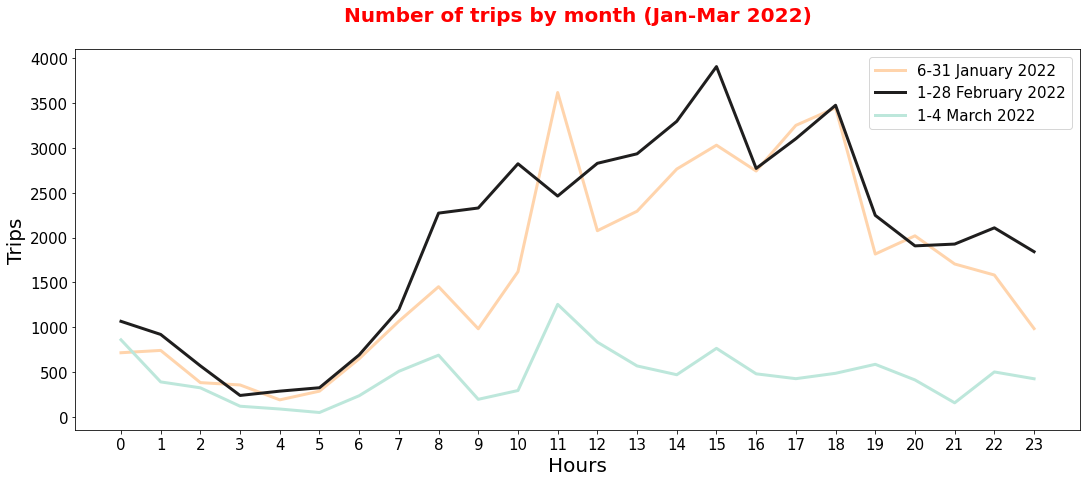

In [191]:
plt.figure(figsize = (18, 7))
sns.lineplot(x = 'hour', y = 'num_trips', hue = 'month', data = m, palette = "icefire_r", linewidth = 3) 
plt.title("Number of trips by month (Jan-Mar 2022)\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Hours", size = 20, color = "black")
plt.ylabel("Trips", size = 20, color = "black")
plt.legend(['6-31 January 2022', '1-28 February 2022', '1-4 March 2022'], prop={'size': 15})
plt.xticks(range(0,24), size = 15)
plt.yticks(size = 15)
plt.show()

### year 2021

In [192]:
data = df[df.year==2021]
print(data.date.min(), data.date.max())

2021-01-11 2021-12-31


In [193]:
m = data.groupby(['month', 'hour'])['month'].agg(["count"]).reset_index()
m.columns = ['month', 'hour', 'num_trips']
m

,month,hour,num_trips
0,1,6,4
1,1,7,144
2,1,8,162
3,1,9,69
4,1,10,93
...,...,...,...
237,12,19,474
238,12,20,386
239,12,21,197
240,12,22,123


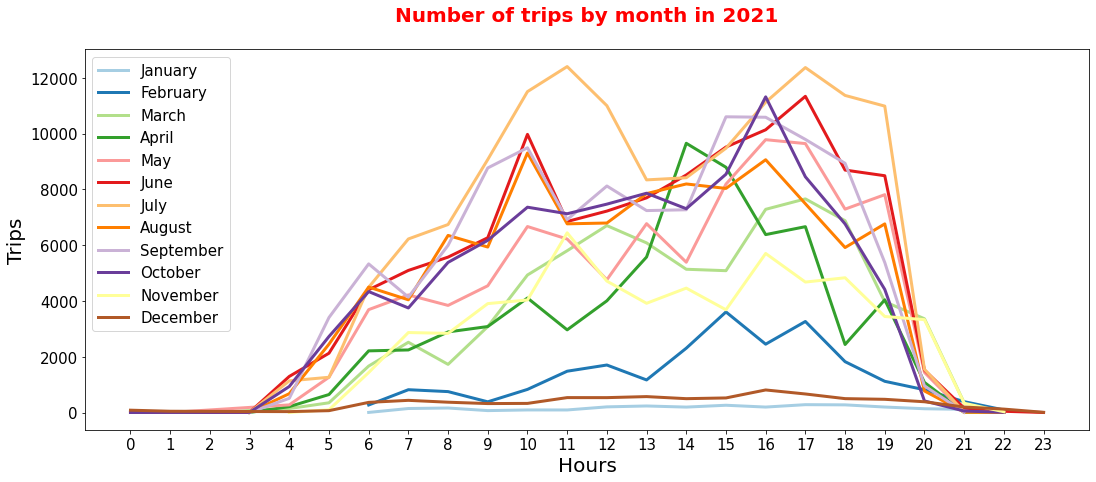

In [194]:
plt.figure(figsize = (18, 7))
sns.lineplot(x = 'hour', y = 'num_trips', hue = 'month', data = m, palette = "Paired", linewidth = 3) 
plt.title("Number of trips by month in 2021\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Hours", size = 20, color = "black")
plt.ylabel("Trips", size = 20, color = "black")
plt.legend(['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], prop={'size': 15}, loc='upper left')
plt.xticks(range(0,24), size = 15)
plt.yticks(size = 15)
plt.show()

### year 2020

In [195]:
data = df[df.year==2020]
print(data.date.min(), data.date.max()) # less than a month

2020-11-30 2020-12-28


In [196]:
m = data.groupby(['month', 'hour'])['month'].agg(["count"]).reset_index()
m.columns = ['month', 'hour', 'num_trips']
m

,month,hour,num_trips
0,11,14,1
1,11,15,5
2,11,16,6
3,11,17,8
4,11,18,6
5,11,19,8
6,11,20,2
7,11,21,6
8,12,5,1
9,12,6,11


### Cumulative time of usage per day

(May add cumulative time of usage per day **per scooter**: use `tripsv3.parquet` for this, as it contains the ID of the vehicles.) 

### year 2022

In [197]:
df['day'] = pd.to_datetime(df['date']).dt.day
df.head()

,index,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,date,unique_id,day,hour,month,year
0,80411,BIT,Bit Mobility,00000bf0-0000-1000-a6a0-5b7d6a617b60,2020-11-30 14:32:20+00:00,46.069790,11.121222,0,2020-11-30,00000bf0-0000-1000-a6a0-5b7d6a617b60_2020-11-30,30,14,11,2020
1,80618,BIT,Bit Mobility,00000bf0-0000-1000-a6a0-5b7d6a617b60,2020-11-30 15:23:13+00:00,46.069786,11.115813,1,2020-11-30,00000bf0-0000-1000-a6a0-5b7d6a617b60_2020-11-30,30,15,11,2020
2,80423,BIT,Bit Mobility,00001d90-0000-1000-8b30-5b7d6a617b60,2020-11-30 15:37:44+00:00,46.070271,11.120379,0,2020-11-30,00001d90-0000-1000-8b30-5b7d6a617b60_2020-11-30,30,15,11,2020
3,80625,BIT,Bit Mobility,0000210d-0000-1000-8d7d-5b7d6a617b60,2020-11-30 15:42:50+00:00,46.067200,11.126792,0,2020-11-30,0000210d-0000-1000-8d7d-5b7d6a617b60_2020-11-30,30,15,11,2020
4,80412,BIT,Bit Mobility,00001d90-0000-1000-8b30-5b7d6a617b60,2020-11-30 15:46:11+00:00,46.068718,11.115568,1,2020-11-30,00001d90-0000-1000-8b30-5b7d6a617b60_2020-11-30,30,15,11,2020


In [198]:
# extract only 2022
original_df = df
df = df[df.year==2022]

In [199]:
df = df[(df.date >= dt.date(2022, 1, 11)) & (df.date <= dt.date(2022, 3, 4))] # try compare usage in the same period of time (Jan-Mar 2021 & Jan-Mar 2022), so filter common period

In [200]:
df = df.reset_index()

In [201]:
# dictionary with IDs as keys ("unique_id") and as value a dict with "point_sequence" as key and "point_timestamp" as value
d={}
for r in range(len(df)):
  if df.unique_id[r] not in d.keys():
    inner_d = {}
    inner_d[df.point_sequence[r]]=df.point_timestamp[r]
    d[df.unique_id[r]] = inner_d
  else:
    d[df.unique_id[r]][df.point_sequence[r]]=df.point_timestamp[r]

In [202]:
# for each trip, record date and trip duration
duration=[]
day=[]
for k in d.keys():
  duration.append(d[k][max(d[k].keys())] - d[k][min(d[k].keys())])
  day.append(d[k][min(d[k].keys())].date()) # missing starting pt n. 0 ?? 
  
drtn = pd.DataFrame({'day':day, 'duration':duration})
drtn

,day,duration
0,2022-01-11,0 days 00:12:08
1,2022-01-11,0 days 00:05:47
2,2022-01-11,0 days 00:03:21
3,2022-01-11,0 days 00:04:12
4,2022-01-11,0 days 00:03:26
...,...,...
8327,2022-03-04,0 days 00:06:43
8328,2022-03-04,0 days 00:00:16
8329,2022-03-04,0 days 00:09:11
8330,2022-03-04,0 days 00:08:02


In [203]:
# cumulative duration of trips, for each date
drtn_by_day = drtn.groupby(['day'])['duration'].agg(["sum"]).reset_index()
drtn_by_day.columns = ['day', 'cumduration']
drtn_by_day.head()

,day,cumduration
0,2022-01-11,0 days 03:58:44
1,2022-01-12,0 days 07:02:04
2,2022-01-13,0 days 05:02:47
3,2022-01-14,0 days 07:21:30
4,2022-01-15,0 days 05:14:57


In [204]:
drtn_by_day['cumduration_time']=(pd.Timestamp('now').normalize() + drtn_by_day.cumduration).dt.time # pd.Timestamp('now').normalize() -> reset to midnight

In [205]:
drtn_by_day['cumduration_int'] = round(drtn_by_day.cumduration.dt.seconds / 60, 0)
drtn_by_day['cumduration_int'] = drtn_by_day['cumduration_int'].astype('int64', copy=False)
drtn_by_day.head()

,day,cumduration,cumduration_time,cumduration_int
0,2022-01-11,0 days 03:58:44,03:58:44,239
1,2022-01-12,0 days 07:02:04,07:02:04,422
2,2022-01-13,0 days 05:02:47,05:02:47,303
3,2022-01-14,0 days 07:21:30,07:21:30,442
4,2022-01-15,0 days 05:14:57,05:14:57,315


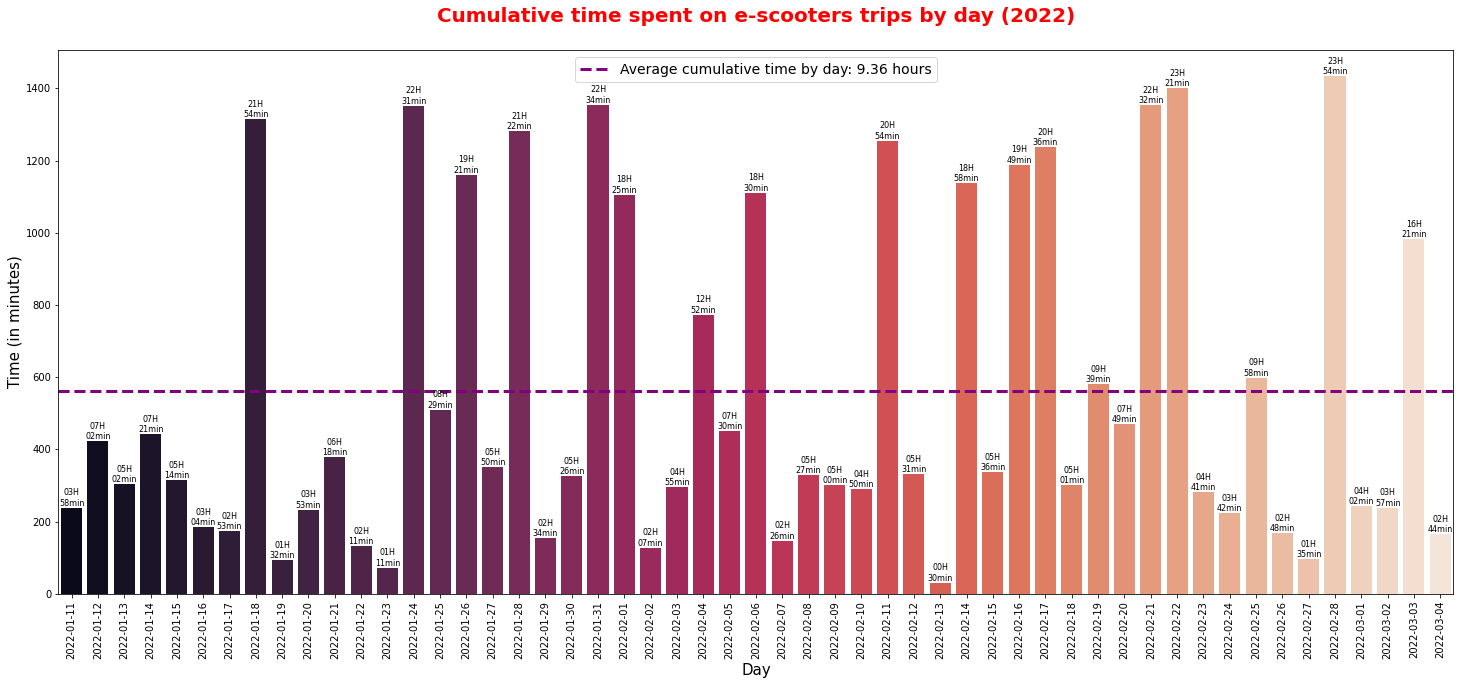

In [211]:
plt.figure(figsize = (25, 10))
plot = sns.barplot(x = "day", y = "cumduration_int", data = drtn_by_day, palette = "rocket")
for p in range(len(plot.patches)):
  plot.annotate(str(drtn_by_day.cumduration_time[p])[:2]+'H\n'+str(drtn_by_day.cumduration_time[p])[3:5]+'min', 
                (plot.patches[p].get_x()+0.4, plot.patches[p].get_height()),
                ha='center', va='bottom',color= 'black', size = 8)
plot.axhline(drtn_by_day["cumduration_int"].mean(), linestyle="--", color="purple", label="Average cumulative time by day: "+str(round(drtn_by_day["cumduration_int"].mean()/60,2))+' hours', linewidth = 3) 
plt.title("Cumulative time spent on e-scooters trips by day (2022)\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Day", size = 15, color = 'black')
plt.ylabel("Time (in minutes)", size = 15, color = 'black')
plt.legend(prop={'size': 14}, loc='upper center')
plt.xticks(size = 10, rotation=90)
plt.yticks(size = 10)
plt.show()

### year 2021

In [227]:
df = original_df[original_df.year==2021]
df = df[(df.date >= dt.date(2021, 1, 11)) & (df.date <= dt.date(2021, 3, 4))] # try compare usage in the same period of time (Jan-Mar 2021 & Jan-Mar 2022)
df = df.reset_index()

In [228]:
df.date.min(), df.date.max()

(datetime.date(2021, 1, 11), datetime.date(2021, 3, 4))

In [229]:
# dictionary with IDs as keys ("unique_id") and as value a dict with "point_sequence" as key and "point_timestamp" as value
d={}
for r in range(len(df)):
  if df.unique_id[r] not in d.keys():
    inner_d = {}
    inner_d[df.point_sequence[r]]=df.point_timestamp[r]
    d[df.unique_id[r]] = inner_d
  else:
    d[df.unique_id[r]][df.point_sequence[r]]=df.point_timestamp[r]
# for each trip, record date and trip duration
duration=[]
day=[]
for k in d.keys():
  duration.append(d[k][max(d[k].keys())] - d[k][min(d[k].keys())])
  day.append(d[k][min(d[k].keys())].date()) # missing starting pt n. 0 ?? 
  
drtn = pd.DataFrame({'day':day, 'duration':duration})
drtn

,day,duration
0,2021-01-11,0 days 02:30:14
1,2021-01-11,0 days 01:23:32
2,2021-01-11,0 days 00:06:49
3,2021-01-11,0 days 00:04:31
4,2021-01-11,0 days 00:04:21
...,...,...
5735,2021-03-04,0 days 00:06:08
5736,2021-03-04,0 days 00:07:42
5737,2021-03-04,0 days 00:08:14
5738,2021-03-04,0 days 00:03:18


In [230]:
# cumulative duration of trips, for each date
drtn_by_day = drtn.groupby(['day'])['duration'].agg(["sum"]).reset_index()
drtn_by_day.columns = ['day', 'cumduration']
# drtn_by_day.head()

drtn_by_day['cumduration_time']=(pd.Timestamp('now').normalize() + drtn_by_day.cumduration).dt.time

drtn_by_day['cumduration_int'] = round(drtn_by_day.cumduration.dt.seconds / 60, 0)
drtn_by_day['cumduration_int'] = drtn_by_day['cumduration_int'].astype('int64', copy=False)
# drtn_by_day.head()

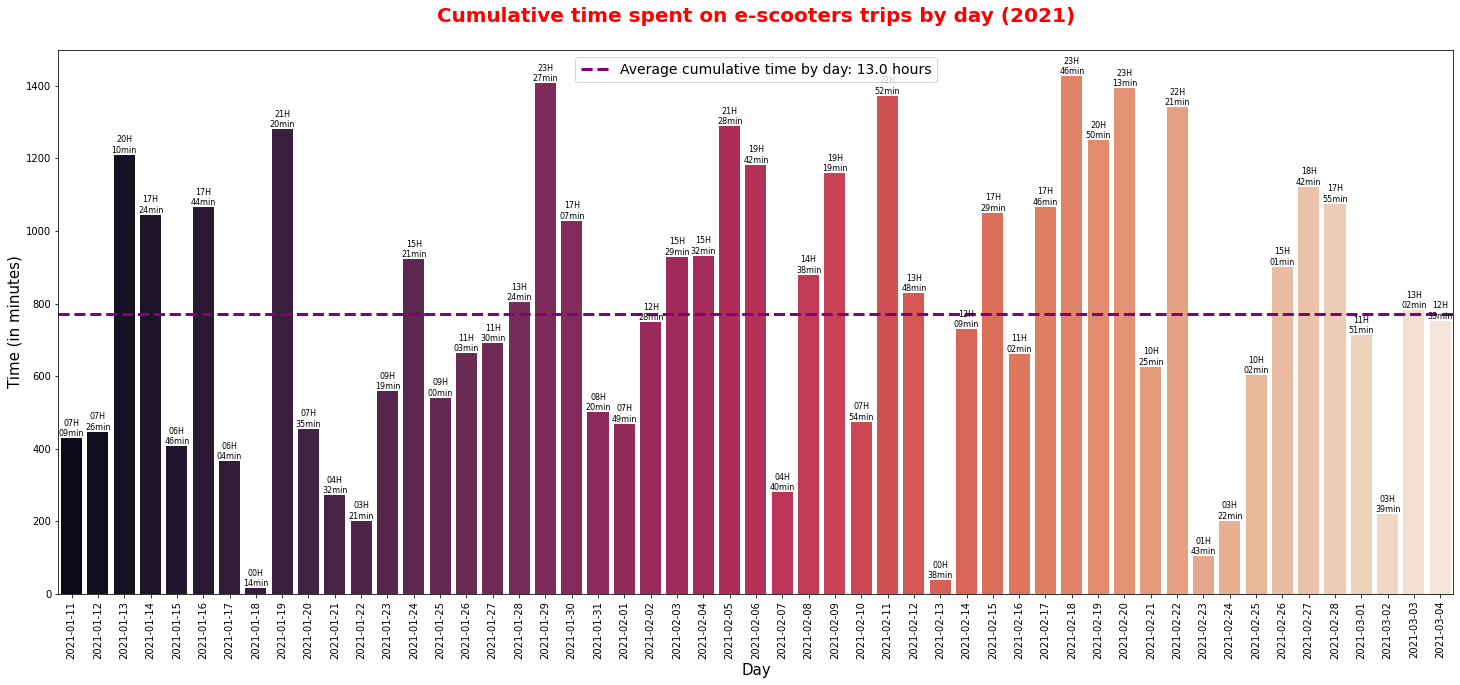

In [234]:
plt.figure(figsize = (25, 10))
plot = sns.barplot(x = "day", y = "cumduration_int", data = drtn_by_day, palette = "rocket")
for p in range(len(plot.patches)):
  plot.annotate(str(drtn_by_day.cumduration_time[p])[:2]+'H\n'+str(drtn_by_day.cumduration_time[p])[3:5]+'min', 
                (plot.patches[p].get_x()+0.4, plot.patches[p].get_height()),
                ha='center', va='bottom',color= 'black', size = 8)
plot.axhline(drtn_by_day["cumduration_int"].mean(), linestyle="--", color="purple", label="Average cumulative time by day: "+str(round(drtn_by_day["cumduration_int"].mean()/60,0))+' hours', linewidth = 3) 
plt.title("Cumulative time spent on e-scooters trips by day (2021)\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Day", size = 15, color = 'black')
plt.ylabel("Time (in minutes)", size = 15, color = 'black')
plt.legend(prop={'size': 14}, loc='upper center')
plt.xticks(size = 10, rotation=90)
plt.yticks(size = 10)
plt.show()

There was a significant drop in the average cumulative time per day in 2022 with respect to 2021, in the same time period (11 January - 4 March), going from almost 13 hours in 2021 to 9 hours and 36 minutes in 2022.